In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import geopandas as gpd
from pathlib import Path
import unicodedata

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import mean_absolute_error, r2_score

# Carga de datos y configuración base

In [16]:

DATASET_PATH = "../../dataset_final/dataset_distritos_procesado.csv"
df = pd.read_csv(DATASET_PATH)
df_full = df.copy()


KEY_COLS = [
    "id_dera","cod_mun","nombre","provincia","id_distrito","nombre_distrito",
    "__did__","municipio","year","quarter","q_num","period","period_ord","amen_key"
]

TARGET_COL = "price_next"

#quitar filas sin target futuro
df = df.dropna(subset=[TARGET_COL]).copy()

# Selección de variables y prevención de leakage

In [17]:
# Columnas a excluir
EXCLUDE_EXACT = {
    TARGET_COL,
    "price_vs_mun_next",
    "target_delta",
    "target_delta_vs_mun",
    "price_vs_mun_next_1y",
    "target_delta_vs_mun_1y",
    "target_up",
    "target_delta_vs_mun_roll",
    "target_delta_vs_mun_roll_bin",
}

# Reglas anti-leakage
def is_leaky(col: str) -> bool:
    col_low = col.lower()
    if col in KEY_COLS: return True
    if col in EXCLUDE_EXACT: return True
    if col_low.startswith("target_"): return True
    if "next" in col_low: return True
    return False

feature_cols = [c for c in df.columns if not is_leaky(c)]

y = df[TARGET_COL].copy()
X = df[feature_cols].copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X_num = X[num_cols].copy()

pipe_full = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA())
])

pipe_full.fit(X_num)
pca = pipe_full.named_steps["pca"]

# Split temporal train/val/test

In [18]:
def split_train_val_test_by_year(df, year_col="year", val_years=1, test_year=None):
    years = sorted(df[year_col].dropna().unique().astype(int))
    if test_year is None:
        test_year = years[-1]

    years_before_test = [y for y in years if y < test_year]
    if len(years_before_test) < val_years:
        raise ValueError("No hay suficientes años antes de test_year para val_years")

    val_years_list = years_before_test[-val_years:]
    train = df[df[year_col] < min(val_years_list)].copy()
    val = df[df[year_col].isin(val_years_list)].copy()
    test = df[df[year_col] == test_year].copy()
    return train, val, test, val_years_list, test_year


def prepare_xy_for_forecast(df, X_num, target_future="price_next", target_now="price_m2"):
    mask = df[target_future].notna()
    df_model = df.loc[mask].copy()
    X_model = X_num.loc[df_model.index].copy()
    y_future = df_model[target_future].copy()
    y_now = df_model[target_now].copy()
    return df_model, X_model, y_future, y_now


# Pipeline de modelado

In [19]:
def make_pipeline(estimator, pca_components=None, imputer_strategy="median"):
    steps = [
        ("imputer", SimpleImputer(strategy=imputer_strategy)),
        ("scaler", StandardScaler()),
    ]
    if pca_components is not None:
        steps.append(("pca", PCA(n_components=pca_components, random_state=42)))
    steps.append(("model", estimator))
    return Pipeline(steps)


# Entrenamiento, búsqueda de hiperparámetros y evaluación

In [20]:
def fit_and_evaluate(
    estimator,
    param_grid,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    pca_components=None,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=0
):
    pipe = make_pipeline(estimator, pca_components=pca_components)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        verbose=verbose
    )
    grid.fit(X_train, y_train)

    pred_val = grid.predict(X_val)
    pred_test = grid.predict(X_test)

    out = {
        "best_estimator": grid.best_estimator_,
        "best_params": grid.best_params_,
        "val_mae": mean_absolute_error(y_val, pred_val),
        "val_r2": r2_score(y_val, pred_val),
        "test_mae": mean_absolute_error(y_test, pred_test),
        "test_r2": r2_score(y_test, pred_test),
        "pred_val": pred_val,
        "pred_test": pred_test,
    }
    return out


## Loop de experimentos

In [21]:
def run_experiments(
    model_specs,
    pca_list,    
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0
):
    results = []
    fitted = {}

    for model_name, spec in model_specs.items():
        for pca_k in pca_list:
            tag = f"{model_name}__pca_{pca_k if pca_k is not None else 'none'}"
            print(f"\n----- {tag} -----")

            out = fit_and_evaluate(
                estimator=spec["estimator"],
                param_grid=spec["param_grid"],
                X_train=X_train, y_train=y_train,
                X_val=X_val, y_val=y_val,
                X_test=X_test, y_test=y_test,
                pca_components=pca_k,
                scoring=scoring,
                cv=cv,
                n_jobs=n_jobs,
                verbose=verbose
            )

            fitted[(model_name, pca_k)] = out
            results.append({
                "model": model_name,
                "pca_components": pca_k,
                "val_mae": out["val_mae"],
                "val_r2": out["val_r2"],
                "test_mae": out["test_mae"],
                "test_r2": out["test_r2"],
                "best_params": out["best_params"],
            })

    results_df = pd.DataFrame(results).sort_values(["val_mae", "test_mae"])
    return results_df, fitted


# Catálogo de modelos a comparar

In [22]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor

model_specs = {
    "ridge": {
        "estimator": Ridge(random_state=42),
        "param_grid": {
            "model__alpha": [0.1, 1.0, 10.0, 100.0]
        }
    },
    "lasso": {
        "estimator": Lasso(random_state=42, max_iter=20000),
        "param_grid": {
            "model__alpha": [0.001, 0.01, 0.1, 1.0]
        }
    },
    "elasticnet": {
        "estimator": ElasticNet(random_state=42, max_iter=20000),
        "param_grid": {
            "model__alpha": [0.001, 0.01, 0.1, 1.0],
            "model__l1_ratio": [0.1, 0.5, 0.9]
        }
    },
    "rf": {
        "estimator": RandomForestRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [300, 600],
            "model__max_depth": [10, 20, None],
            "model__min_samples_leaf": [1, 3, 5],
            "model__min_samples_split": [2, 5, 10],
            "model__max_features": ["sqrt", 0.5, 1.0],
        }
    },
    "adaboost": {
        "estimator": AdaBoostRegressor(
            estimator=DecisionTreeRegressor(random_state=42),
            random_state=42
        ),
        "param_grid": {
            "model__n_estimators": [200, 400, 800],
            "model__learning_rate": [0.03, 0.1, 0.3],
            "model__estimator__max_depth": [2, 3, 4],
            "model__loss": ["linear", "square"],
        }
    },
}

try:
    from xgboost import XGBRegressor
    model_specs["xgb"] = {
        "estimator": XGBRegressor(
            random_state=42,
            n_estimators=800,
            tree_method="hist",
            n_jobs=-1
        ),
        "param_grid": {
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
            "model__reg_lambda": [1.0, 5.0, 10.0],
            "model__min_child_weight": [1, 5],
        }
    }
except Exception as e:
    print("XGBoost no disponible (no instalado).")


# Ejecución del pipeline: preparación, split, experimentos y persistencia

In [23]:
import os
import joblib
import pandas as pd

RESULTS_PATH = "../../resultados/results_experiments.csv"
MODEL_PATH = "../../resultados/best_model.pkl"
ALL_MODELS_PATH = "../../resultados/all_fitted.pkl"


# 1) Preparar datos

df_model, X_model, y_future, y_now = prepare_xy_for_forecast(
    df, X_num, target_future="price_next", target_now="price_m2"
)


# 2) Split temporal

train_df, val_df, test_df, val_years_list, test_year = split_train_val_test_by_year(
    df_model, year_col="year", val_years=1, test_year=2024
)

X_train, y_train = X_model.loc[train_df.index], y_future.loc[train_df.index]
X_val, y_val = X_model.loc[val_df.index], y_future.loc[val_df.index]
X_test, y_test = X_model.loc[test_df.index], y_future.loc[test_df.index]


# 3) Ejecutar o cargar experimentos

if os.path.exists(RESULTS_PATH) and os.path.exists(MODEL_PATH):
    print(" Cargando resultados y modelo guardados...")
    
    results_df = pd.read_csv(RESULTS_PATH)
    best = joblib.load(MODEL_PATH)
    fitted = joblib.load(ALL_MODELS_PATH)

else:
    print(" Ejecutando experimentos...")

    pca_list = [None, 25, 38, 50]

    results_df, fitted = run_experiments(
        model_specs=model_specs,
        pca_list=pca_list,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        cv=3,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1
    )

    # elegir mejor modelo
    best_row = results_df.iloc[0]
    best_model_name = best_row["model"]
    best_pca = best_row["pca_components"]

    if pd.isna(best_pca):
        best_pca = None
    else:
        best_pca = int(best_pca)

    best = fitted[(best_model_name, best_pca)]["best_estimator"]

    # guardar resultados
    results_df.to_csv(RESULTS_PATH, index=False)
    joblib.dump(fitted, ALL_MODELS_PATH)
    joblib.dump(best, MODEL_PATH)

    print(" Resultados y modelo guardados")


results_df


 Cargando resultados y modelo guardados...


,model,pca_components,val_mae,val_r2,test_mae,test_r2,best_params
0,lasso,NaN,74.820289,0.984162,78.209535,0.988737,{'model__alpha': 1.0}
1,elasticnet,NaN,81.592566,0.982730,81.372906,0.987713,"{'model__alpha': 0.1, 'model__l1_ratio': 0.9}"
2,ridge,NaN,84.159948,0.982147,83.091227,0.987361,{'model__alpha': 10.0}
3,lasso,50.0,95.041763,0.974602,98.228487,0.983454,{'model__alpha': 0.001}
4,ridge,50.0,95.042275,0.974601,98.229329,0.983454,{'model__alpha': 0.1}
5,elasticnet,50.0,95.042362,0.974601,98.228490,0.983454,"{'model__alpha': 0.001, 'model__l1_ratio': 0.9}"
6,adaboost,NaN,100.935515,0.966107,122.287103,0.959510,"{'model__estimator__max_depth': 4, 'model__lea..."
7,xgb,NaN,103.098195,0.956916,129.274447,0.936544,"{'model__colsample_bytree': 1.0, 'model__learn..."
8,rf,NaN,104.696302,0.942886,135.849796,0.924552,"{'model__max_depth': 10, 'model__max_features'..."
9,lasso,38.0,134.204954,0.962502,156.428409,0.962826,{'model__alpha': 1.0}


# Evaluación en test y dataset de salida

In [24]:
out_test = test_df.copy()
pred_test = best.predict(X_test)

out_test["price_now"] = df.loc[out_test.index, "price_m2"].values
out_test["price_next_real"] = df.loc[out_test.index, "price_next"].values
out_test["price_next_pred"] = pred_test

out_test["delta_real"] = out_test["price_next_real"] - out_test["price_now"]
out_test["delta_pred"] = out_test["price_next_pred"] - out_test["price_now"]

out_test["abs_error_price"] = (out_test["price_next_pred"] - out_test["price_next_real"]).abs()
out_test["abs_error_delta"] = (out_test["delta_pred"] - out_test["delta_real"]).abs()

out_test.to_csv("../../resultados/out_test_completo.csv", index=False)

#  ranking
ranking_test = out_test.sort_values("delta_pred", ascending=False)
ranking_test.to_csv("../../resultados/ranking_test.csv", index=False)

# Análisis de casos (mejores/peores predicciones)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error

def build_case_tables(
    test_df: pd.DataFrame,
    df_full: pd.DataFrame,
    best_model,
    X_test,
    *,
    price_now_col_in_df_full: str = "price_m2",
    price_next_col_in_df_full: str = "price_next",
    id_cols=("municipio", "id_distrito", "nombre_distrito", "year", "quarter"),
    top_n: int = 10,
):
    """
    Construye tablas de casos:
      - mejor ajuste (menor error de precio)
      - peor ajuste (mayor error de precio)
      - ranking por delta_pred (top)
    También devuelve out_test completo con columnas de errores.

    """
    out_test = test_df.copy()

    # 1) Predicción
    pred_test = best_model.predict(X_test)
    out_test["price_next_pred"] = pred_test

    # 2) Precios reales (ahora y next)
    out_test["price_now"] = df_full.loc[out_test.index, price_now_col_in_df_full].values
    out_test["price_next_real"] = df_full.loc[out_test.index, price_next_col_in_df_full].values

    # 3) Deltas (variación trimestral)
    out_test["delta_real"] = out_test["price_next_real"] - out_test["price_now"]
    out_test["delta_pred"] = out_test["price_next_pred"] - out_test["price_now"]

    # 4) Errores
    out_test["abs_error_price"] = (out_test["price_next_real"] - out_test["price_next_pred"]).abs()
    out_test["error_price"] = out_test["price_next_pred"] - out_test["price_next_real"]

    out_test["abs_error_delta"] = (out_test["delta_real"] - out_test["delta_pred"]).abs()
    out_test["error_delta"] = out_test["delta_pred"] - out_test["delta_real"]

    # Métricas
    mae_price = mean_absolute_error(out_test["price_next_real"], out_test["price_next_pred"])
    mae_delta = mean_absolute_error(out_test["delta_real"], out_test["delta_pred"])
    corr_delta = out_test["delta_real"].corr(out_test["delta_pred"])

    show_cols = [c for c in id_cols if c in out_test.columns] + [
        "price_now", "price_next_real", "price_next_pred", "abs_error_price",
        "delta_real", "delta_pred", "abs_error_delta"
    ]

    best_price = out_test.sort_values("abs_error_price").head(top_n)[show_cols]
    worst_price = out_test.sort_values("abs_error_price", ascending=False).head(top_n)[show_cols]

    top_delta_pred = out_test.sort_values("delta_pred", ascending=False).head(top_n)[show_cols]

    return {
        "out_test": out_test,
        "metrics": {"mae_price": mae_price, "mae_delta": mae_delta, "corr_delta": corr_delta},
        "tables": {
            "best_price": best_price,
            "worst_price": worst_price,
            "top_delta_pred": top_delta_pred,
        }
    }



def plot_error_hist(out_test: pd.DataFrame, col: str = "error_price", title: str = "Distribución del error"):
    """
    Histograma de errores (pred - real).
    """
    plt.figure()
    plt.hist(out_test[col].dropna().to_numpy(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.title(title)
    plt.show()




{'mae_price': 78.20953455235207, 'mae_delta': 78.20953455235207, 'corr_delta': np.float64(0.09363055954422038)}


,municipio,id_distrito,nombre_distrito,year,quarter,price_now,price_next_real,price_next_pred,abs_error_price,delta_real,delta_pred,abs_error_delta
3005,torremolinos,4,Montemar,2024,Q3,3133.00,3238.33,3238.093739,0.236261,105.33,105.093739,0.236261
2398,mijas,6,Mijas Pueblo,2024,Q3,3156.33,3243.67,3244.199116,0.529116,87.34,87.869116,0.529116
2436,mijas,7,Mijas Golf,2024,Q1,2489.67,2571.67,2572.635661,0.965661,82.00,82.965661,0.965661
1110,estepona,5,Estepona Pueblo,2024,Q3,3310.00,3390.00,3388.702733,1.297267,80.00,78.702733,1.297267
1108,estepona,5,Estepona Pueblo,2024,Q1,3039.33,3122.67,3121.219427,1.450573,83.34,81.889427,1.450573
662,benalmadena,2,El Higuerón - Capellanía,2024,Q3,4212.00,4313.00,4311.040057,1.959943,101.00,99.040057,1.959943
117,alhaurin_de_la_torre,4,El Romeral - Peñón de Zapata,2024,Q2,1935.33,1979.33,1981.380695,2.050695,44.00,46.050695,2.050695
2076,marbella,3,Nagüeles-Milla de Oro,2024,Q1,6022.33,6182.33,6179.147804,3.182196,160.00,156.817804,3.182196
2883,torremolinos,1,El Pinillo,2024,Q1,2602.33,2711.67,2708.202499,3.467501,109.34,105.872499,3.467501
2804,rincon_de_la_victoria,8,Añoreta Golf - Paraíso del Sol,2024,Q2,2191.33,2271.00,2274.520165,3.520165,79.67,83.190165,3.520165


,municipio,id_distrito,nombre_distrito,year,quarter,price_now,price_next_real,price_next_pred,abs_error_price,delta_real,delta_pred,abs_error_delta
1149,estepona,6,Punta Plata,2024,Q2,4088.67,4509.33,4163.973879,345.356121,420.66,75.303879,345.356121
2763,rincon_de_la_victoria,6,Torre de Benagalbón,2024,Q1,3034.00,2812.00,3114.060535,302.060535,-222.00,80.060535,302.060535
2156,marbella,5,Río Real-Los Monteros,2024,Q1,4421.33,4283.00,4576.446999,293.446999,-138.33,155.116999,293.446999
1270,fuengirola,1,Zona Sohail,2024,Q3,4175.33,3993.00,4284.963802,291.963802,-182.33,109.633802,291.963802
353,benahavis,1,La Zagaleta,2024,Q1,6876.33,6711.33,6983.089983,271.759983,-165.00,106.759983,271.759983
196,alhaurin_de_la_torre,6,Platero - El Limón,2024,Q2,1689.67,2004.00,1740.111615,263.888385,314.33,50.441615,263.888385
981,estepona,1,Altos de Estepona,2024,Q2,3008.67,3387.33,3133.283966,254.046034,378.66,124.613966,254.046034
1022,estepona,2,Playa Bahía Dorada,2024,Q3,3076.33,3387.00,3153.167878,233.832122,310.67,76.837878,233.832122
982,estepona,1,Altos de Estepona,2024,Q3,3387.33,3729.33,3501.400087,227.929913,342.00,114.070087,227.929913
1716,malaga,5,Palma-Palmilla,2024,Q1,1262.67,1125.67,1350.765583,225.095583,-137.00,88.095583,225.095583


,municipio,id_distrito,nombre_distrito,year,quarter,price_now,price_next_real,price_next_pred,abs_error_price,delta_real,delta_pred,abs_error_delta
2158,marbella,5,Río Real-Los Monteros,2024,Q3,4323.00,4335.67,4489.323908,153.653908,12.67,166.323908,153.653908
2116,marbella,4,Marbella Pueblo,2024,Q1,3831.33,4052.33,3996.540401,55.789599,221.00,165.210401,55.789599
2157,marbella,5,Río Real-Los Monteros,2024,Q2,4283.00,4323.00,4447.719380,124.719380,40.00,164.719380,124.719380
1997,marbella,1,San Pedro de Alcántara,2024,Q2,3968.67,4228.00,4130.414304,97.585696,259.33,161.744304,97.585696
2117,marbella,4,Marbella Pueblo,2024,Q2,4052.33,4218.33,4212.775996,5.554004,166.00,160.445996,5.554004
1996,marbella,1,San Pedro de Alcántara,2024,Q1,3866.33,3968.67,4026.367195,57.697195,102.34,160.037195,57.697195
2118,marbella,4,Marbella Pueblo,2024,Q3,4218.33,4205.33,4376.598722,171.268722,-13.00,158.268722,171.268722
2078,marbella,3,Nagüeles-Milla de Oro,2024,Q3,6311.67,6308.67,6469.041928,160.371928,-3.00,157.371928,160.371928
2076,marbella,3,Nagüeles-Milla de Oro,2024,Q1,6022.33,6182.33,6179.147804,3.182196,160.00,156.817804,3.182196
1998,marbella,1,San Pedro de Alcántara,2024,Q3,4228.00,4416.67,4384.357398,32.312602,188.67,156.357398,32.312602


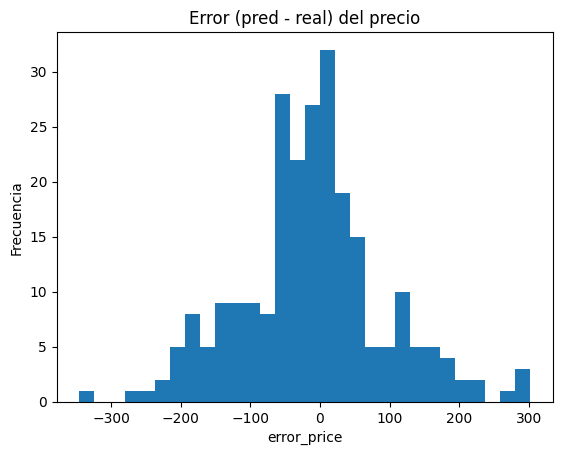

In [26]:
result = build_case_tables(
    test_df=test_df,
    df_full=df,
    best_model=best,
    X_test=X_test,
    price_now_col_in_df_full="price_m2",
    price_next_col_in_df_full="price_next",
    id_cols=("municipio", "id_distrito", "nombre_distrito", "year", "quarter"),
    top_n=10,
)

print(result["metrics"])
display(result["tables"]["best_price"])
display(result["tables"]["worst_price"])

display(result["tables"]["top_delta_pred"])

out_test = result["out_test"]
plot_error_hist(out_test, col="error_price", title="Error (pred - real) del precio")

# Exportar para visualización (test)

In [27]:
BASE_DIR = r"C:\Users\sergi\Desktop\Master\TFM\dataset\district_level"
RESULTS_CSV = r"../../resultados/out_test_completo.csv"
OUT_DIR = Path(r"../../resultados").resolve()
OUT_GPKG = str((OUT_DIR / "distritos_resultados.gpkg").resolve())
OUT_LAYER = "distritos_resultados"

# CRS objetivo
TARGET_EPSG = 25830

YEAR_FILTER = None      
QUARTER_FILTER = None   

# Campos esperados en la capa de distritos
ID_DIST_FIELDS = ["id_distrito", "id_dist", "district_id", "iddistrito"]
NAME_DIST_FIELDS = ["nombre_distrito", "name_distrito", "district", "nombre"]
MUN_FIELDS = ["municipio", "nombre_municipio", "mun", "nombre"]

LAYER_NAME_FIXED = None


def norm_mun(s: str) -> str:
    """
    Normaliza nombres de municipio
    """
    if s is None:
        return ""
    s = str(s).strip().lower()

    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))

    s = s.replace("-", " ").replace(".", " ")
    s = "_".join(s.split())
    return s


def _find_first_existing(df_cols, candidates):
    cols_lower = {c.lower(): c for c in df_cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

def _detect_district_layer(gpkg_path: str):
    layers = gpd.list_layers(gpkg_path)
    for _, row in layers.iterrows():
        name = row["name"]
        try:
            gdf = gpd.read_file(gpkg_path, layer=name)
        except Exception:
            continue
        if gdf.empty:
            continue
        geom_ok = gdf.geom_type.isin(["Polygon", "MultiPolygon"]).any()
        if not geom_ok:
            continue
        id_col = _find_first_existing(gdf.columns, ID_DIST_FIELDS)
        if id_col is None:
            continue
        return name
    return None

def _force_target_crs(gdf: gpd.GeoDataFrame, target_epsg: int) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        raise ValueError("La capa no tiene CRS definido (crs=None). Asigna CRS en QGIS o en el archivo.")
    if gdf.crs.to_epsg() != target_epsg:
        gdf = gdf.to_crs(epsg=target_epsg)
    return gdf

def _read_districts_from_gpkg(gpkg_path: str, municipio_name_from_folder: str):
    layer = LAYER_NAME_FIXED or _detect_district_layer(gpkg_path)
    if layer is None:
        raise ValueError(f"No se pudo detectar capa de distritos en: {gpkg_path}")

    gdf = gpd.read_file(gpkg_path, layer=layer)
    gdf = _force_target_crs(gdf, TARGET_EPSG)

    id_col = _find_first_existing(gdf.columns, ID_DIST_FIELDS)
    name_col = _find_first_existing(gdf.columns, NAME_DIST_FIELDS)
    mun_col = _find_first_existing(gdf.columns, MUN_FIELDS)

    if id_col is None:
        raise ValueError(f"Falta campo id_distrito en {gpkg_path} (capa {layer}).")

    gdf = gdf.copy()

    # municipio
    if mun_col is not None:
        gdf["municipio_raw"] = gdf[mun_col].astype(str)
    else:
        
        gdf["municipio_raw"] = municipio_name_from_folder

    # id_distrito
    gdf["id_distrito"] = pd.to_numeric(gdf[id_col], errors="coerce").astype("Int64")

    # nombre_distrito
    if name_col is not None:
        gdf["nombre_distrito"] = gdf[name_col].astype(str).str.strip()
    else:
        gdf["nombre_distrito"] = None

    gdf["municipio_key"] = gdf["municipio_raw"].apply(norm_mun)

    keep_cols = ["municipio_raw", "municipio_key", "id_distrito", "nombre_distrito", "geometry"]
    return gdf[keep_cols], layer

def _normalize_results(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "municipio" not in df.columns or "id_distrito" not in df.columns:
        raise ValueError(f"El CSV debe tener municipio e id_distrito. Columnas: {list(df.columns)}")

    df["municipio"] = df["municipio"].astype(str)
    df["municipio_key"] = df["municipio"].apply(norm_mun)

    df["id_distrito"] = pd.to_numeric(df["id_distrito"], errors="coerce").astype("Int64")

    if "year" in df.columns:
        df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    if "quarter" in df.columns:
        df["quarter"] = df["quarter"].astype(str).str.strip()

    return df

def _add_error_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # abs_error_price
    if "abs_error_price" not in df.columns and {"price_next_real", "price_next_pred"}.issubset(df.columns):
        df["abs_error_price"] = (df["price_next_pred"] - df["price_next_real"]).abs()

    # abs_error_delta
    if "abs_error_delta" not in df.columns and {"delta_real", "delta_pred"}.issubset(df.columns):
        df["abs_error_delta"] = (df["delta_pred"] - df["delta_real"]).abs()

    # mape_pct
    if "mape_pct" not in df.columns and {"price_next_real", "price_next_pred"}.issubset(df.columns):
        denom = df["price_next_real"].replace(0, pd.NA)
        df["mape_pct"] = ((df["price_next_pred"] - df["price_next_real"]).abs() / denom) * 100

    return df


OUT_DIR.mkdir(parents=True, exist_ok=True)


# CARGAR Y UNIR DISTRITOS

all_districts = []
read_log = []

base = Path(BASE_DIR)
mun_dirs = [p for p in base.iterdir() if p.is_dir()]

for mun_dir in mun_dirs:
    municipio_folder = mun_dir.name.strip()
    gpkg_candidates = list(mun_dir.glob("*.gpkg"))

    if not gpkg_candidates:
        read_log.append((municipio_folder, None, "NO_GPKG", None))
        continue

    gdf_mun = None
    gpkg_path_used = None
    layer_used = None
    err_last = None

    for gpkg_path in gpkg_candidates:
        try:
            gdf_try, layer_try = _read_districts_from_gpkg(str(gpkg_path), municipio_folder)
            gdf_mun = gdf_try
            gpkg_path_used = str(gpkg_path)
            layer_used = layer_try
            break
        except Exception as e:
            err_last = str(e)

    if gdf_mun is None:
        read_log.append((municipio_folder, str(gpkg_candidates[0]), "ERROR", err_last))
        continue

    all_districts.append(gdf_mun)
    read_log.append((municipio_folder, gpkg_path_used, layer_used, int(len(gdf_mun))))

print("Lectura por municipio ")
for row in read_log:
    print(row)

if not all_districts:
    raise RuntimeError("No se han cargado distritos. Revisa BASE_DIR y capas/campos.")

gdf_distritos = gpd.GeoDataFrame(pd.concat(all_districts, ignore_index=True), crs=f"EPSG:{TARGET_EPSG}")


# CARGAR RESULTADOS

df_res = pd.read_csv(RESULTS_CSV)
df_res = _normalize_results(df_res)
df_res = _add_error_metrics(df_res)


# FILTRO TEMPORAL

last_year = None
sel_q = None

if "year" in df_res.columns:
    if YEAR_FILTER is not None:
        last_year = YEAR_FILTER
    else:
        last_year = int(df_res["year"].dropna().max())
    df_res = df_res[df_res["year"] == last_year].copy()

if "quarter" in df_res.columns:
    if QUARTER_FILTER is not None:
        sel_q = QUARTER_FILTER
    else:
        q_order = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
        df_res["_q"] = df_res["quarter"].map(q_order)
        max_q_num = int(df_res["_q"].max())
        sel_q = f"Q{max_q_num}"
        df_res = df_res[df_res["_q"] == max_q_num].drop(columns=["_q"]).copy()
    df_res = df_res[df_res["quarter"] == sel_q].copy()

print("\n--- Filtro temporal aplicado ---")
print("year:", last_year)
print("quarter:", sel_q)
print("Filas resultados tras filtro:", len(df_res))


dup_count = df_res.duplicated(subset=["municipio_key", "id_distrito"]).sum()
if dup_count > 0:
    print(f"AVISO: {dup_count} duplicados por (municipio_key,id_distrito). Agregando medias.")
    numeric_cols = df_res.select_dtypes(include="number").columns.tolist()
    df_res = df_res.groupby(["municipio_key", "id_distrito"], as_index=False)[numeric_cols].mean()


keys_d = set(map(tuple, gdf_distritos[["municipio_key", "id_distrito"]].drop_duplicates().values))
keys_r = set(map(tuple, df_res[["municipio_key", "id_distrito"]].drop_duplicates().values))
matches = len(keys_d & keys_r)

print("\n--- Diagnóstico join ---")
print("Distritos únicos:", len(keys_d))
print("Resultados únicos:", len(keys_r))
print("Matches:", matches)

if matches == 0:
    print("\n No hay matches. Ejemplos distritos:")
    print(gdf_distritos[["municipio_raw","municipio_key","id_distrito"]].drop_duplicates().head(15))
    print("\nEjemplos resultados:")
    print(df_res[["municipio","municipio_key","id_distrito"]].drop_duplicates().head(15))
    raise RuntimeError("No hay coincidencias. Revisa municipio_key/id_distrito.")


#  MERGE Y EXPORTAR

gdf_out = gdf_distritos.merge(
    df_res,
    on=["municipio_key", "id_distrito"],
    how="left",
    indicator=True
)

print("\n_merge counts:")
print(gdf_out["_merge"].value_counts(dropna=False))


gdf_out = gdf_out.drop(columns=["_merge"])

if os.path.exists(OUT_GPKG):
    os.remove(OUT_GPKG)

gdf_out.to_file(OUT_GPKG, layer=OUT_LAYER, driver="GPKG")

print(f"\n OK -> exportado: {OUT_GPKG} (layer: {OUT_LAYER})")

Lectura por municipio 
('alhaurin_de_la_torre', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\alhaurin_de_la_torre\\alhaurin_de_la_torre.gpkg', 'alhaurin_de_la_torre__13_01_terminomunicipal', 9)
('benahavis', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\benahavis\\benahavis.gpkg', 'benahavis__13_01_terminomunicipal', 9)
('benalmadena', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\benalmadena\\benalmadena.gpkg', 'benalmadena__13_01_terminomunicipal', 9)
('estepona', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\estepona\\estepona.gpkg', 'estepona__13_01_terminomunicipal', 8)
('fuengirola', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\fuengirola\\fuengirola.gpkg', 'fuengirola__13_01_terminomunicipal', 9)
('malaga', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\malaga\\malaga.gpkg', 'malaga__13_01_terminomunicipal', 11)
('marbella', 'C:\\Users\\sergi\\Desktop\\Master\

# Baseline vs modelo

In [28]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# baseline: price_next = price_now
out_test["price_next_baseline"] = out_test["price_now"]
out_test["delta_baseline"] = 0

baseline_mae_price = mean_absolute_error(
    out_test["price_next_real"],
    out_test["price_next_baseline"]
)

model_mae_price = mean_absolute_error(
    out_test["price_next_real"],
    out_test["price_next_pred"]
)

print("\n===== BASELINE COMPARISON =====")
print("Baseline MAE price:", baseline_mae_price)
print("Modelo   MAE price:", model_mae_price)
print("Mejora modelo vs baseline:",
      baseline_mae_price - model_mae_price)



# ERROR RELATIVO (%)

mape = np.mean(
    np.abs((out_test["price_next_real"] - out_test["price_next_pred"])
    / out_test["price_next_real"])
) * 100

print("\nMAPE % (error relativo medio):", mape)



#  RANGOS DEL PROBLEMA

print("\n===== RANGOS DE PRECIOS =====")
print("Precio actual (€/m²):")
print(out_test["price_now"].describe())

print("\nPrecio siguiente real (€/m²):")
print(out_test["price_next_real"].describe())

print("\nCambio real entre trimestres (€/m²):")
print(out_test["delta_real"].describe())

print("\nCambio predicho (€/m²):")
print(out_test["delta_pred"].describe())



# ERROR DISTRIBUCIÓN

out_test["abs_error_price"] = np.abs(
    out_test["price_next_real"] - out_test["price_next_pred"]
)

print("\n===== DISTRIBUCIÓN ERROR PRECIO =====")
print(out_test["abs_error_price"].describe())



===== BASELINE COMPARISON =====
Baseline MAE price: 124.8204938271605
Modelo   MAE price: 78.20953455235207
Mejora modelo vs baseline: 46.61095927480844

MAPE % (error relativo medio): 2.4554965123400314

===== RANGOS DE PRECIOS =====
Precio actual (€/m²):
count     243.000000
mean     3246.918971
std       990.203812
min      1033.330000
25%      2541.665000
50%      3060.330000
75%      3872.665000
max      6876.330000
Name: price_now, dtype: float64

Precio siguiente real (€/m²):
count     243.000000
mean     3355.854527
std       995.006131
min      1033.330000
25%      2649.000000
50%      3152.330000
75%      4010.335000
max      6725.330000
Name: price_next_real, dtype: float64

Cambio real entre trimestres (€/m²):
count    243.000000
mean     108.935556
std      103.700649
min     -222.000000
25%       48.170000
50%      102.000000
75%      167.000000
max      420.660000
Name: delta_real, dtype: float64

Cambio predicho (€/m²):
count    243.000000
mean      96.550235
std      

# Rentabilidad esperada (ROI) para el último periodo

In [29]:
# entrenar con todo lo disponible
best.fit(X_model, y_future)

# elegir último periodo observado
q_order = {"Q1":1,"Q2":2,"Q3":3,"Q4":4}
df_full["_q_ord"] = df_full["quarter"].map(q_order)

last_year = int(df_full["year"].max())
last_q = int(df_full.loc[df_full["year"] == last_year, "_q_ord"].max())

df_base = df_full[(df_full["year"] == last_year) & (df_full["_q_ord"] == last_q)].copy()
X_base = df_base[feature_cols].copy()

# predicción
pred_next = best.predict(X_base)

df_base["price_next_pred"] = pred_next
df_base["delta_pred"] = df_base["price_next_pred"] - df_base["price_m2"]

#  ROI (rentabilidad esperada)
df_base["roi_pred"] = (
    df_base["delta_pred"] / df_base["price_m2"]
) * 100

df_base.to_csv("../../resultados/pred_next_roi.csv", index=False)


In [30]:
df_base.sort_values("roi_pred", ascending=False)[
    [
        "municipio","id_distrito","year","quarter","nombre_distrito",
        "price_m2","price_next_pred",
        "delta_pred","roi_pred"
    ]
].head(25)

,municipio,id_distrito,year,quarter,nombre_distrito,price_m2,price_next_pred,delta_pred,roi_pred
1719,malaga,5,2024,Q4,Palma-Palmilla,1072.00,1143.190971,71.190971,6.640949
1311,fuengirola,2,2024,Q4,Centro Ciudad,2893.33,3012.624290,119.294290,4.123079
1879,malaga,9,2024,Q4,Campanillas,2169.33,2254.037019,84.707019,3.904755
1759,malaga,6,2024,Q4,Cruz de Humilladero,2761.33,2866.023304,104.693304,3.791409
1471,fuengirola,6,2024,Q4,Los Pacos,2895.00,3004.284664,109.284664,3.774945
1671,malaga,3,2024,Q4,Ciudad-Jardín,2088.00,2165.682189,77.682189,3.720411
1711,malaga,4,2024,Q4,Bailén-Miraflores,2464.00,2552.699145,88.699145,3.599803
1391,fuengirola,4,2024,Q4,Los Boliches,3071.33,3181.803883,110.473883,3.596940
3086,torremolinos,6,2024,Q4,El Pinar - Palacio de Congresos,2611.00,2704.545395,93.545395,3.582742
1799,malaga,7,2024,Q4,Carretera Cádiz,3360.33,3478.361902,118.031902,3.512509


In [31]:
df_base["roi_pred"].describe()

count    81.000000
mean      2.776755
std       0.714702
min       1.543311
25%       2.320164
50%       2.715168
75%       3.096073
max       6.640949
Name: roi_pred, dtype: float64

# Exportación para QGIS (ROI futuro)

In [33]:
import os
import pandas as pd
import geopandas as gpd
from pathlib import Path
import unicodedata


BASE_DIR = r"C:\Users\sergi\Desktop\Master\TFM\dataset\district_level"
RESULTS_CSV = r"../../resultados/pred_next_roi.csv"
OUT_DIR = Path(r"../../resultados").resolve()
OUT_GPKG = str((OUT_DIR / "distritos_pred_inversion.gpkg").resolve())
OUT_LAYER = "pred_inversion" 
TARGET_EPSG = 25830

YEAR_FILTER = None
QUARTER_FILTER = None

ID_DIST_FIELDS = ["id_distrito", "id_dist", "district_id", "iddistrito"]
NAME_DIST_FIELDS = ["nombre_distrito", "name_distrito", "district", "nombre"]
MUN_FIELDS = ["municipio", "nombre_municipio", "mun", "nombre"]

LAYER_NAME_FIXED = None


def norm_mun(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    s = s.replace("-", " ").replace(".", " ")
    s = "_".join(s.split())
    return s


def _add_investment_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Asegura que existan:
    - delta_pred = price_next_pred - price_m2
    - roi_pred = 100 * delta_pred / price_m2   (porcentaje)
    """
    df = df.copy()

    if "price_m2" in df.columns:
        p0 = "price_m2"
    elif "price_now" in df.columns:
        p0 = "price_now"
    else:
        p0 = None

    # delta_pred
    if "delta_pred" not in df.columns:
        if p0 and "price_next_pred" in df.columns:
            df["delta_pred"] = df["price_next_pred"] - df[p0]

    # roi_pred (%)
    if "roi_pred" not in df.columns:
        if p0 and "delta_pred" in df.columns:
            denom = df[p0].replace(0, pd.NA)
            df["roi_pred"] = (df["delta_pred"] / denom) * 100

    return df


OUT_DIR.mkdir(parents=True, exist_ok=True)


# CARGAR Y UNIR DISTRITOS

all_districts = []
read_log = []

base = Path(BASE_DIR)
mun_dirs = [p for p in base.iterdir() if p.is_dir()]

for mun_dir in mun_dirs:
    municipio_folder = mun_dir.name.strip()
    gpkg_candidates = list(mun_dir.glob("*.gpkg"))

    if not gpkg_candidates:
        read_log.append((municipio_folder, None, "NO_GPKG", None))
        continue

    gdf_mun = None
    gpkg_path_used = None
    layer_used = None
    err_last = None

    for gpkg_path in gpkg_candidates:
        try:
            gdf_try, layer_try = _read_districts_from_gpkg(str(gpkg_path), municipio_folder)
            gdf_mun = gdf_try
            gpkg_path_used = str(gpkg_path)
            layer_used = layer_try
            break
        except Exception as e:
            err_last = str(e)

    if gdf_mun is None:
        read_log.append((municipio_folder, str(gpkg_candidates[0]), "ERROR", err_last))
        continue

    all_districts.append(gdf_mun)
    read_log.append((municipio_folder, gpkg_path_used, layer_used, int(len(gdf_mun))))

print("Lectura por municipio")
for row in read_log:
    print(row)

if not all_districts:
    raise RuntimeError("No se han cargado distritos. Revisa BASE_DIR y capas/campos.")

gdf_distritos = gpd.GeoDataFrame(pd.concat(all_districts, ignore_index=True), crs=f"EPSG:{TARGET_EPSG}")

# CARGAR RESULTADOS

df_res = pd.read_csv(RESULTS_CSV)
df_res = _normalize_results(df_res)
df_res = _add_investment_metrics(df_res)


# FILTRO TEMPORAL 

if "year" in df_res.columns and (YEAR_FILTER is not None):
    df_res = df_res[df_res["year"] == YEAR_FILTER].copy()

if "quarter" in df_res.columns and (QUARTER_FILTER is not None):
    df_res = df_res[df_res["quarter"] == QUARTER_FILTER].copy()


dup_count = df_res.duplicated(subset=["municipio_key", "id_distrito"]).sum()
if dup_count > 0:
    print(f"AVISO: {dup_count} duplicados por (municipio_key,id_distrito). Agregando medias.")
    numeric_cols = df_res.select_dtypes(include="number").columns.tolist()
    df_res = df_res.groupby(["municipio_key", "id_distrito"], as_index=False)[numeric_cols].mean()

print("\nFilas resultados:", len(df_res))
print("Columnas inversión disponibles:", [c for c in ["price_next_pred", "delta_pred", "roi_pred"] if c in df_res.columns])


keys_d = set(map(tuple, gdf_distritos[["municipio_key", "id_distrito"]].drop_duplicates().values))
keys_r = set(map(tuple, df_res[["municipio_key", "id_distrito"]].drop_duplicates().values))
matches = len(keys_d & keys_r)

print("\n--- Diagnóstico join ---")
print("Distritos únicos:", len(keys_d))
print("Resultados únicos:", len(keys_r))
print("Matches:", matches)

if matches == 0:
    print("\n No hay matches. Ejemplos distritos:")
    print(gdf_distritos[["municipio_raw","municipio_key","id_distrito"]].drop_duplicates().head(15))
    print("\nEjemplos resultados:")
    print(df_res[["municipio","municipio_key","id_distrito"]].drop_duplicates().head(15))
    raise RuntimeError("No hay coincidencias. Revisa municipio_key/id_distrito.")


# MERGE Y EXPORTAR

gdf_out = gdf_distritos.merge(
    df_res,
    on=["municipio_key", "id_distrito"],
    how="left",
    indicator=True
)

print("\n_merge counts:")
print(gdf_out["_merge"].value_counts(dropna=False))

gdf_out = gdf_out.drop(columns=["_merge"])


if os.path.exists(OUT_GPKG):
    os.remove(OUT_GPKG)

gdf_out.to_file(OUT_GPKG, layer=OUT_LAYER, driver="GPKG")

print(f"\n OK -> exportado: {OUT_GPKG} (layer: {OUT_LAYER})")

Lectura por municipio
('alhaurin_de_la_torre', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\alhaurin_de_la_torre\\alhaurin_de_la_torre.gpkg', 'alhaurin_de_la_torre__13_01_terminomunicipal', 9)
('benahavis', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\benahavis\\benahavis.gpkg', 'benahavis__13_01_terminomunicipal', 9)
('benalmadena', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\benalmadena\\benalmadena.gpkg', 'benalmadena__13_01_terminomunicipal', 9)
('estepona', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\estepona\\estepona.gpkg', 'estepona__13_01_terminomunicipal', 8)
('fuengirola', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\fuengirola\\fuengirola.gpkg', 'fuengirola__13_01_terminomunicipal', 9)
('malaga', 'C:\\Users\\sergi\\Desktop\\Master\\TFM\\dataset\\district_level\\malaga\\malaga.gpkg', 'malaga__13_01_terminomunicipal', 11)
('marbella', 'C:\\Users\\sergi\\Desktop\\Master\\

# Interpretabilidad: importancia de variables

In [ ]:
# modelo final
model = best.named_steps["model"]

coefs = model.coef_

fi = pd.DataFrame({
    "feature": feature_cols,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
})


# sacar variables de precio / tendencia / lag
mask_price_family = fi["feature"].str.contains(
    r"price|trend|lag|mun_price",
    case=False,
    regex=True
)

fi_urban = fi[~mask_price_family].sort_values("abs_coef", ascending=False)

fi_urban.head(20)

,feature,coef,abs_coef
29,dist_food_m,-3.688167,3.688167
38,pct_building_commercial,2.917265,2.917265
62,pct_act_utilities,2.739517,2.739517
25,dist_pt_stop_m,-2.657116,2.657116
11,n_poi_waste,2.403182,2.403182
107,green_to_building,2.280759,2.280759
10,n_poi_utilities,2.245442,2.245442
69,area_act_shop_m2,-2.214599,2.214599
61,area_act_utilities_m2,-2.128787,2.128787
28,dist_education_m,1.927781,1.927781


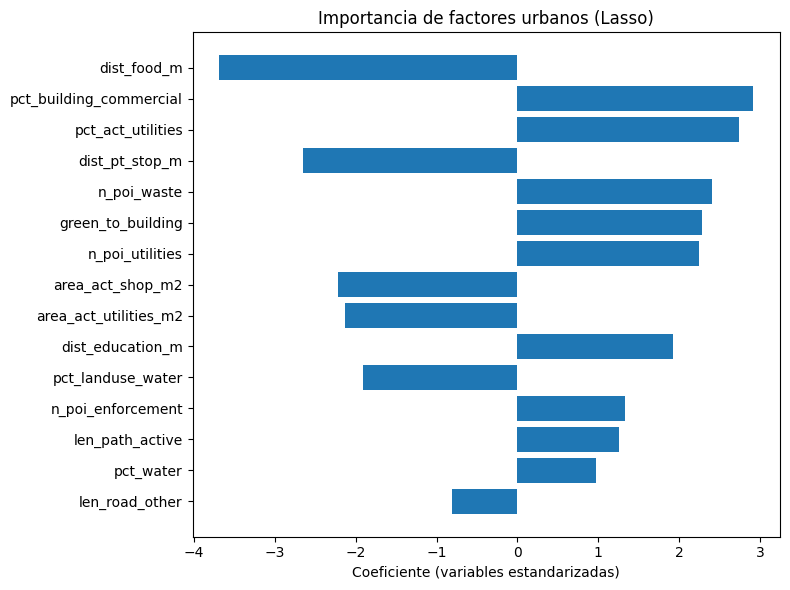

In [ ]:
top = fi_urban.head(15)

plt.figure(figsize=(8,6))
plt.barh(top["feature"][::-1], top["coef"][::-1])
plt.title("Importancia de factores urbanos (Lasso)")
plt.xlabel("Coeficiente (variables estandarizadas)")
plt.tight_layout()
plt.show()